# Experiment — Feature-Selection-Sanity-Check (einmalig)

> **Takeaway —** *(nach dem Volllauf eintragen)* — Erwartung: KEIN Feature-Subset schlägt
> das volle legitime Set um mehr als Rauschen (±0.003 AUC). Wenn das so rauskommt, ist
> das Thema "brauchen wir algorithmische Feature Selection?" empirisch erledigt und
> dokumentiert — und wir fassen es nie wieder an.

## Worum es geht (und worum NICHT)

**Die Frage:** Bringt es messbar etwas, aus unseren ~25 legitimen Features algorithmisch
ein "optimales" Subset zu wählen — statt einfach alle zu behalten und die Regularisierung
arbeiten zu lassen?

**Was dieses Notebook NICHT ist:** Leakage-Erkennung. Selektionsalgorithmen ranken nach
prädiktiver Stärke — Leakage ist maximale prädiktive Stärke und würde von jedem dieser
Verfahren auf Platz 1 gewählt (unser Country-Leak hätte jede Selektion überlebt und
gewonnen). Leakage findet man nur über Prozesswissen: *Was ist WANN bekannt?*

## Die drei Familien der Feature Selection (Crashkurs)

| Familie | Idee | Stärke | Blinder Fleck |
|---|---|---|---|
| **Filter** | Jedes Feature einzeln gegen das Target testen (Korrelation, Chi², Mutual Information) | billig, modellunabhängig | sieht keine Interaktionen; zwei einzeln schwache Features können zusammen stark sein; redundanzblind |
| **Wrapper** | Modell wiederholt mit verschiedenen Subsets trainieren (RFE, Forward/Backward) | misst echten Modell-Nutzen inkl. Interaktionen | teuer (viele Fits); Subset gilt nur für DIESES Modell; überfittet leicht die Validierung, wenn nicht sauber genested |
| **Embedded** | Selektion passiert IM Training (L1 setzt Gewichte auf 0; Bäume splitten nie auf Irrelevantem) | gratis, pro Modell automatisch, stabil | Auswahl ist implizit — man muss sie sich anschauen (Koeffizienten/Importances), um sie zu sehen |

**Wichtigste Lektion — das Nesting-Prinzip:** Feature-Auswahl ist Teil des Trainings.
Wer auf den GLEICHEN Daten auswählt UND bewertet, belügt sich (die Auswahl hat die
Bewertungsdaten schon gesehen → zu optimistisch). Deshalb arbeitet dieses Notebook
dreistufig: ausgewählt wird auf einem **internen** Stück des Trainingsblocks, final
verglichen wird **einmal** auf Val. Test bleibt im Tresor — wie immer.

```
train_core (älteste ~85% von train)  → Modelle fitten
train_tail (neueste ~15% von train)  → Selektions-Entscheidungen treffen
val                                  → finaler Vergleich der Kandidaten-Sets (1x)
test                                 → unberührt
```


In [1]:
# =============================================================================
# §0 SETUP
# =============================================================================
# sys/Path: um die Projektwurzel zu finden und src importierbar zu machen.
import sys
from pathlib import Path
# Von notebooks/experiments/ aus so lange hochlaufen, bis pyproject.toml auftaucht.
_here = Path.cwd().resolve()
while not (_here / "pyproject.toml").exists() and _here != _here.parent:
    _here = _here.parent
# Projektwurzel in den Python-Suchpfad einhängen.
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))

# Die Standard-Werkzeuge: Mathe, Tabellen, Plots.
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Projekt-Helfer: Datenlader, kanonischer Feature-Roster, Stil, Pfade.
from src.data_loader import load_clean_reservations
from src.features import model_feature_roster
from src import apply_stayery_style, color, tables_dir

# sklearn-Bausteine — jede wird unten an ihrer Einsatzstelle erklärt.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score, average_precision_score

# Warn-Spam aus, Stayery-Plotstil an, Output-Ordner sicherstellen.
warnings.filterwarnings("ignore")
apply_stayery_style()
TAB = tables_dir() / "00_audit"; TAB.mkdir(parents=True, exist_ok=True)

# Fester Seed: gleiche Zufallsentscheidungen bei jedem Lauf (Reproduzierbarkeit).
SEED = 42
# Zielspalte im Clean-Parquet (1 = storniert, 0 = angereist).
TARGET = "status"
print("Setup ok.")

Setup ok.


## §1 — Daten + das dreistufige Nesting-Design

Wir bauen `train_core` / `train_tail` **chronologisch** (nicht zufällig), aus demselben
Grund wie überall im Projekt: Selektions-Entscheidungen sollen unter denselben
Bedingungen fallen wie später echte Entscheidungen — Vergangenheit entscheidet,
nahe Zukunft bewertet.

Hinweis: Die drei Leak-Profilfelder sind seit 2026-06-12 bereits im Roster (`src/features.py NON_FEATURE_COLS`) ausgeschlossen — die explizite LEAKY-Zeile im Code bleibt als Gürtel-und-Hosenträger drin.

In [2]:
# =============================================================================
# §1 LADEN + SPLITS
# =============================================================================
# Clean-Parquet laden; Zeilen ohne Target sicherheitshalber raus.
df = load_clean_reservations().dropna(subset=[TARGET]).copy()

# Kanonischer Roster aus src/ — dieselbe Quelle wie alle anderen Experimente.
NUM, CAT = model_feature_roster(df)

# Roster schliesst die Leak-Felder seit 2026-06-12 selbst aus; Zeile bleibt als Doppelsicherung.
LEAKY = ["guest_country_region", "primaryGuest_preferredLanguage", "travelPurpose"]
CAT = [c for c in CAT if c not in LEAKY]
# ALL_FEATURES = die "Grundgesamtheit", über die selektiert wird.
ALL_FEATURES = NUM + CAT

# Projekt-Splits: train zum Arbeiten, val für den finalen Vergleich, test bleibt zu.
tr = df[df["temporal_split"] == "train"].copy()
va = df[df["temporal_split"] == "val"].copy()

# train chronologisch in core (alt, 85%) und tail (neu, 15%) teilen:
# core = Modelle fitten | tail = Selektions-Entscheidungen bewerten.
tr = tr.sort_values("arrival")                     # nach Anreise sortieren
n_core = int(len(tr) * 0.85)                       # Schnittpunkt bei 85%
core, tail = tr.iloc[:n_core], tr.iloc[n_core:]    # Vergangenheit / nahe Zukunft

# Zielvektoren als simple 0/1-Arrays.
y_core = core[TARGET].astype(int).to_numpy()
y_tail = tail[TARGET].astype(int).to_numpy()
y_va   = va[TARGET].astype(int).to_numpy()

print(f"core {len(core):,} | tail {len(tail):,} | val {len(va):,} | "
      f"{len(NUM)} numerische + {len(CAT)} kategorische Features (Leaky-Felder raus)")

core 86,401 | tail 15,248 | val 25,563 | 18 numerische + 4 kategorische Features (Leaky-Felder raus)


In [3]:
# =============================================================================
# §1b PIPELINE-FABRIK — eine Funktion, die für ein beliebiges Feature-Subset
# die komplette Preprocessing+Modell-Pipeline baut (wie in 01, nur parametrisiert).
# =============================================================================
def make_pipe(features, model):
    # Das Subset in numerisch/kategorisch zerlegen (Reihenfolge egal).
    num = [f for f in features if f in NUM]
    cat = [f for f in features if f in CAT]
    # Numerisch: Median-Imputer + Standardisierung (wie 01 §4).
    num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                         ("sc",  StandardScaler())])
    # Kategorisch: Modus-Imputer + One-Hot (unbekannte Level -> alles 0).
    cat_pipe = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                         ("oh",  OneHotEncoder(handle_unknown="ignore",
                                              sparse_output=False))])  # dicht: HistGB kann kein sparse
    # ColumnTransformer verteilt die Spalten, Pipeline hängt das Modell dahinter.
    return Pipeline([("prep", ColumnTransformer([("num", num_pipe, num),
                                                 ("cat", cat_pipe, cat)])),
                     ("clf", model)])

# Kleine Helfer: fit auf core, AUC auf einem Bewertungs-Frame zurückgeben.
def fit_score(features, model, X_fit, y_fit, X_ev, y_ev):
    pipe = make_pipe(features, model)               # Pipeline fürs Subset bauen
    pipe.fit(X_fit[features], y_fit)                # nur auf den Fit-Daten lernen
    p = pipe.predict_proba(X_ev[features])[:, 1]    # Wahrscheinlichkeiten fürs Eval-Set
    return roc_auc_score(y_ev, p), pipe             # AUC + die Pipeline selbst

# Die zwei Modell-Bauer (frische Instanz pro Aufruf, damit nichts Zustand teilt).
mk_logreg = lambda C=1.0, l1r=0.5: LogisticRegression(
    penalty="elasticnet", l1_ratio=l1r, C=C, solver="saga", max_iter=2000, random_state=SEED)
mk_histgb = lambda: HistGradientBoostingClassifier(
    max_depth=8, learning_rate=0.05, max_iter=300, random_state=SEED)
print("Pipeline-Fabrik bereit.")

Pipeline-Fabrik bereit.


## §2 — Familie 1: FILTER (Mutual Information)

**Idee:** Jedes Feature einzeln fragen: "Wie viel Information lieferst du über das
Target?" Mutual Information (MI) misst das auch für nichtlineare Zusammenhänge
(im Gegensatz zur Korrelation) — 0 = nichts, größer = mehr.

**Wozu gut:** schneller Überblick, Grob-Screening bei hunderten Features.
**Blinder Fleck (live zu beobachten):** MI ist univariat. Ein Feature, das nur IM
ZUSAMMENSPIEL wirkt (z.B. `arrival_month` via Saisonalität pro Haus), sieht einzeln
schwach aus. Deshalb treffen wir hier KEINE Entscheidung — wir schauen nur, ob das
Ranking grob mit unserem Domänenwissen übereinstimmt.

*Technik-Detail:* MI wird per Nächste-Nachbarn-Schätzung berechnet — auf 100k Zeilen
langsam, daher Stichprobe von 20.000 (für ein Ranking völlig ausreichend).

In [4]:
# =============================================================================
# §2 FILTER: MUTUAL-INFORMATION-RANKING (nur Diagnose, keine Entscheidung)
# =============================================================================
# Stichprobe aus core ziehen (MI-Schätzung ist O(n log n) pro Feature — 20k reicht).
samp = core.sample(min(20000, len(core)), random_state=SEED)

# MI braucht eine reine Zahlenmatrix -> unsere Standard-Vorverarbeitung benutzen,
# aber OHNE Modell (nur der "prep"-Teil der Pipeline).
prep = make_pipe(ALL_FEATURES, mk_histgb()).named_steps["prep"]
Xs = prep.fit_transform(samp[ALL_FEATURES])         # fit+transform auf der Stichprobe
Xs = Xs.toarray() if hasattr(Xs, "toarray") else np.asarray(Xs)  # sparse -> dicht

# Klarnamen der Modell-Spalten (z.B. "cat__channelCode_Booking.com") holen.
col_names = prep.get_feature_names_out()

# MI jeder Modell-Spalte gegen das Target schätzen.
mi = mutual_info_classif(Xs, samp[TARGET].astype(int), random_state=SEED)

# Spalten-MI zu ROH-Feature-MI aggregieren (Maximum über die One-Hot-Spalten eines
# Features — "wie stark ist die stärkste Ausprägung?").
mi_raw = {}
for name, v in zip(col_names, mi):
    raw = name.split("__")[1]                        # "cat__channelCode_Booking.com"
    raw = next((f for f in ALL_FEATURES if raw.startswith(f)), raw)  # -> "channelCode"
    mi_raw[raw] = max(mi_raw.get(raw, 0.0), float(v))

# Als sortierte Tabelle ausgeben + speichern.
mi_tab = (pd.Series(mi_raw, name="mutual_info").sort_values(ascending=False)
          .to_frame())
print("Mutual-Information-Ranking (pro Roh-Feature, Maximum über seine Spalten):")
print(mi_tab.round(4).to_string())
mi_tab.to_csv(TAB / "feature_selection_mi_ranking.csv")

Mutual-Information-Ranking (pro Roh-Feature, Maximum über seine Spalten):
                             mutual_info
lead_time_days                    0.0453
gross_amount                      0.0385
log_gross_amount                  0.0366
diff_gross_cancellation_fee       0.0246
ratePlan_type                     0.0235
gross_per_night                   0.0224
los_nights                        0.0177
ratePlan_category                 0.0168
company_prior_cancel_rate         0.0167
stay_bucket                       0.0093
channelCode                       0.0065
has_company                       0.0048
company_prior_bookings            0.0032
has_group                         0.0029
has_promo                         0.0026
has_corporate_code                0.0023
adults_n                          0.0018
is_weekend_arrival                0.0015
arrival_month                     0.0011
has_children                      0.0009
arrival_dow                       0.0009
is_repeat_company       

## §3 — Familie 2: EMBEDDED (der L1-Pfad)

**Idee:** Die ElasticNet-LogReg aus 01 macht Selektion bereits beim Training: Der
L1-Anteil drückt Gewichte nutzloser Spalten auf exakt 0. Der Regler dafür ist `C` —
klein = starke Regularisierung = wenige aktive Features.

Wir laufen den Pfad ab: für jedes C fitten (auf core), zählen, wie viele Spalten aktiv
bleiben, und messen die AUC (auf tail). **Die Lehre steht in der Kurvenform:** Die AUC
bleibt typischerweise über einen weiten Bereich flach, während Features verschwinden —
und bricht erst ein, wenn die Regularisierung Substanz wegfrisst. Genau das heißt
"Selektion kann das volle Set höchstens BILLIGER machen, nicht BESSER".

  C=0.001   aktive Spalten   15/73  tail-AUC 0.7471
  C=0.003   aktive Spalten   24/73  tail-AUC 0.7509
  C=0.01    aktive Spalten   28/73  tail-AUC 0.7524
  C=0.03    aktive Spalten   35/73  tail-AUC 0.7523
  C=0.1     aktive Spalten   49/73  tail-AUC 0.7524
  C=0.3     aktive Spalten   61/73  tail-AUC 0.7525
  C=1.0     aktive Spalten   66/73  tail-AUC 0.7525
  C=10.0    aktive Spalten   73/73  tail-AUC 0.7521


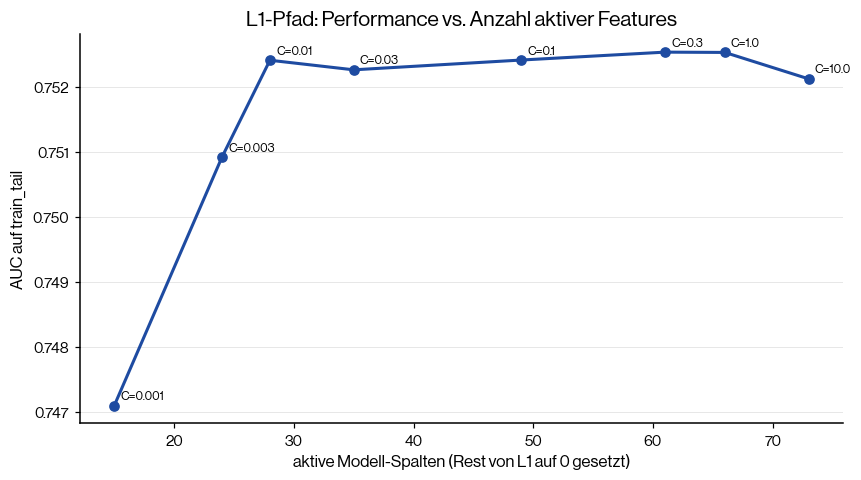

In [5]:
# =============================================================================
# §3 EMBEDDED: L1-PFAD (C-Sweep der ElasticNet-LogReg)
# =============================================================================
# Der Regler-Bereich: von sehr streng (0.001) bis praktisch unreguliert (10).
C_GRID = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 10.0]

l1_rows = []
for C in C_GRID:
    # Pipeline mit dieser Regularisierungsstärke bauen und auf core fitten.
    auc, pipe = fit_score(ALL_FEATURES, mk_logreg(C=C), core, y_core, tail, y_tail)
    # Koeffizienten des gefitteten Modells herausholen ...
    coefs = pipe.named_steps["clf"].coef_.ravel()
    # ... und zählen, wie viele NICHT auf 0 gedrückt wurden (= aktive Spalten).
    n_active = int((np.abs(coefs) > 1e-8).sum())
    l1_rows.append({"C": C, "active_columns": n_active,
                    "total_columns": len(coefs), "auc_tail": auc})
    print(f"  C={C:<7} aktive Spalten {n_active:>4}/{len(coefs)}  tail-AUC {auc:.4f}")

l1_path = pd.DataFrame(l1_rows)

# Plot: x = aktive Spalten, y = AUC -> die "flache Schulter" sichtbar machen.
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(l1_path["active_columns"], l1_path["auc_tail"], marker="o", color=color("blue"))
for _, r in l1_path.iterrows():                      # jeden Punkt mit seinem C beschriften
    ax.annotate(f"C={r['C']}", (r["active_columns"], r["auc_tail"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("aktive Modell-Spalten (Rest von L1 auf 0 gesetzt)")
ax.set_ylabel("AUC auf train_tail")
ax.set_title("L1-Pfad: Performance vs. Anzahl aktiver Features")
fig.tight_layout(); plt.show()

## §4 — Familie 3: WRAPPER (Backward-Elimination, geführt durch Permutation Importance)

**Idee:** Das Modell selbst entscheiden lassen, was es braucht: schwächste Features
entfernen → neu fitten → messen → wiederholen. Das ist die RFE-Logik.

**Zwei ehrliche Praxis-Notizen:**
1. sklearns fertiges `RFE` braucht `coef_` oder `feature_importances_` — unser HistGB
   stellt keine Importances bereit (bitte ggf. in der aktuellen sklearn-Doku
   gegenprüfen). Wir bauen die Schleife daher von Hand mit **Permutation Importance**
   als Ranking — das ist sogar lehrreicher, weil nichts in einer Blackbox passiert,
   und es arbeitet auf ROH-Feature-Ebene (ganze Spalten samt ihrer One-Hots), nicht
   auf einzelnen Dummy-Spalten.
2. **Nesting beachten:** Ranking und Eliminationsentscheidungen passieren auf
   core/tail. Val sieht von alledem nichts bis zum Finale in §5.

In [6]:
# =============================================================================
# §4 WRAPPER: PERMUTATION-RANKING + SCHRITTWEISES WEGLASSEN (HistGB)
# =============================================================================
# Schritt 1: Volles Modell auf core fitten — die Referenz.
auc_full, pipe_full = fit_score(ALL_FEATURES, mk_histgb(), core, y_core, tail, y_tail)
print(f"volles Set ({len(ALL_FEATURES)} Features): tail-AUC {auc_full:.4f}")

# Schritt 2: Permutation Importance auf einer tail-Stichprobe — pro ROH-Feature:
# Spalte durchmischen, AUC-Verlust messen (5 Wiederholungen gegen Zufallsglück).
tail_s = tail.sample(min(8000, len(tail)), random_state=SEED)   # Stichprobe spart Zeit
perm = permutation_importance(pipe_full, tail_s[ALL_FEATURES],
                              tail_s[TARGET].astype(int),
                              scoring="roc_auc", n_repeats=5,
                              random_state=SEED, n_jobs=-1)
# Ranking: schwächstes Feature zuerst (das fliegt als erstes raus).
rank = (pd.Series(perm.importances_mean, index=ALL_FEATURES)
        .sort_values())
print("\nschwächste 8 laut Permutation:", list(rank.index[:8]))

# Schritt 3: Schrittweise die schwächsten k Features entfernen und neu messen.
DROP_STEPS = [0, 4, 8, 12, 16, 20]                 # wie viele der schwächsten raus?
wrap_rows = []
for k in DROP_STEPS:
    feats = [f for f in ALL_FEATURES if f not in set(rank.index[:k])]  # Subset bauen
    auc, _ = fit_score(feats, mk_histgb(), core, y_core, tail, y_tail) # fit + messen
    wrap_rows.append({"dropped_weakest": k, "n_features": len(feats), "auc_tail": auc})
    print(f"  -{k:>2} schwächste -> {len(feats):>2} Features | tail-AUC {auc:.4f}")
wrap_path = pd.DataFrame(wrap_rows)

volles Set (22 Features): tail-AUC 0.7999

schwächste 8 laut Permutation: ['has_corporate_code', 'is_repeat_company', 'log_gross_amount', 'is_weekend_arrival', 'has_children', 'has_promo', 'stay_bucket', 'arrival_month']
  - 0 schwächste -> 22 Features | tail-AUC 0.7999
  - 4 schwächste -> 18 Features | tail-AUC 0.7991
  - 8 schwächste -> 14 Features | tail-AUC 0.7925
  -12 schwächste -> 10 Features | tail-AUC 0.7942
  -16 schwächste ->  6 Features | tail-AUC 0.7924
  -20 schwächste ->  2 Features | tail-AUC 0.7433


## §5 — Das Finale: Kandidaten-Sets EINMAL auf Val

Jede Familie nominiert ihren Kandidaten, dann wird **ein einziges Mal** auf Val
verglichen (fit auf dem KOMPLETTEN train = core+tail, denn die interne Teilung war
nur fürs Auswählen da):

1. **Volles Set** — unsere Default-These
2. **Bestes Wrapper-Subset** — das kleinste Set, dessen tail-AUC max. 0.002 unter
   dem vollen lag (Sparsamkeits-Regel: so klein wie möglich ohne echten Verlust)
3. LogReg läuft mit dem Projekt-Default C=1.0 auf beiden Sets mit — als Querprüfung,
   dass die Subset-Wahl nicht nur dem Baum schmeckt.

**Entscheidungsregel (vorab festgelegt, damit wir uns nichts schönreden):** Ein Subset
wird nur dann ernsthaft erwogen, wenn es das volle Set auf Val um **> 0.003 AUC**
schlägt (die Rauschband-Breite aus unseren Benchmarks). Erwartung: tut es nicht.

In [7]:
# =============================================================================
# §5 FINALER VERGLEICH AUF VAL (einmalig!)
# =============================================================================
# Kandidat Wrapper: kleinstes Set mit tail-AUC >= (volles Set - 0.002).
ok = wrap_path[wrap_path["auc_tail"] >= auc_full - 0.002]
k_best = int(ok["dropped_weakest"].max())            # so viele Schwächste dürfen weg
cand_wrapper = [f for f in ALL_FEATURES if f not in set(rank.index[:k_best])]
print(f"Wrapper-Kandidat: volle {len(ALL_FEATURES)} -> {len(cand_wrapper)} Features "
      f"(die {k_best} schwächsten entfernt)\n")

# Beide Sets x beide Modelle: fit auf GANZ train (core+tail), bewerten auf val.
final_rows = []
for set_name, feats in [("full_set", ALL_FEATURES), ("wrapper_subset", cand_wrapper)]:
    for model_name, mk in [("histgb", mk_histgb), ("logreg", lambda: mk_logreg(C=1.0))]:
        auc, _ = fit_score(feats, mk(), tr, tr[TARGET].astype(int).to_numpy(), va, y_va)
        final_rows.append({"set": set_name, "model": model_name,
                           "n_features": len(feats), "auc_val": auc})
final = pd.DataFrame(final_rows)

# Übersicht drucken + Delta ausweisen.
piv = final.pivot(index="model", columns="set", values="auc_val")
piv["delta (subset - full)"] = piv["wrapper_subset"] - piv["full_set"]
print(piv.round(4).to_string())
print("\nEntscheidungsregel: Subset nur adoptieren, wenn delta > +0.003. Sonst: volles Set bleibt.")

# Alles für die Nachwelt speichern (Audit-Trail).
out = pd.concat([l1_path.assign(part="l1_path"),
                 wrap_path.assign(part="wrapper_path"),
                 final.assign(part="final_val")], ignore_index=True)
out.to_csv(TAB / "feature_selection_sanity.csv", index=False)
print(f"\ngespeichert -> {TAB / 'feature_selection_sanity.csv'}")

Wrapper-Kandidat: volle 22 -> 18 Features (die 4 schwächsten entfernt)

set     full_set  wrapper_subset  delta (subset - full)
model                                                  
histgb    0.8054          0.8057                 0.0003
logreg    0.7624          0.7635                 0.0010

Entscheidungsregel: Subset nur adoptieren, wenn delta > +0.003. Sonst: volles Set bleibt.

gespeichert -> /Users/ruby.grambauer/Documents/DEV/OverbookingAnalyse/reports/tables/00_audit/feature_selection_sanity.csv


## §6 — Der größere Werkzeugkasten (Nachschlage-Katalog)

Was es sonst noch gibt, wann es sich lohnt — und wann nicht. *(Diesen Block kannst du
später aus jedem Production-Code löschen — er ist dein Spickzettel.)*

**Filter-Familie**
- **Variance Threshold** — wirft (nahezu) konstante Spalten raus. Trivial, immer okay.
  Unser `has_free_cancel_window` (konstant 1) wäre genau so aufgefallen.
- **Chi² / ANOVA F-Test** — klassische univariate Tests (kategorisch/numerisch gegen
  Target). Schnell, aber gleiche Blindheit wie MI: keine Interaktionen, keine Redundanz.
- **mRMR** (minimum Redundancy, Maximum Relevance) — wählt Features, die viel übers
  Target sagen und wenig übereinander. Der klügste Filter; lohnt ab ~100+ Features.

**Wrapper-Familie**
- **RFE / RFECV** — sklearn-Standard; braucht `coef_`/`feature_importances_`. RFECV
  wählt die Feature-Anzahl per CV selbst. Muss zwingend GENESTED laufen.
- **SequentialFeatureSelector** (Forward/Backward) — wie RFE, aber modellagnostisch
  (bewertet per CV statt per Koeffizient). Noch teurer: O(p²) Modell-Fits.
- **Genetische Algorithmen / exhaustive Suche** — Subset-Suche als Optimierung.
  Bei p=25 gibt es 33 Mio. Subsets; praktisch nie das Geld wert.

**Embedded-Familie**
- **L1 / ElasticNet** — haben wir (01). Der C-Sweep oben IST die Methode.
- **Tree Importances** (Gain/Split-Counts bei XGBoost) — gratis, aber verzerrt
  zugunsten hochkardinaler Features; Permutation Importance ist die fairere Brille.

**Robustheits-Schicht (die interessantesten Ideen für später)**
- **Null-Importance / Target Permutation** — Target zufällig mischen, Modell fitten,
  Importances messen → das ist die "Importance aus purem Zufall". Echte Features
  müssen deutlich darüber liegen. Sehr eleganter Schutz gegen Selbstbetrug.
- **Boruta** — formalisiert genau das: kämpft jedes Feature gegen seine durchmischte
  Schattenkopie. Beliebt, gründlich, langsam. (Paket `BorutaPy` — wäre bei uns erst
  zu installieren, ist nicht im pyproject; Verfügbarkeit/Wartungszustand bitte prüfen.)
- **Stability Selection** — Selektion auf vielen Bootstrap-Stichproben wiederholen;
  nur Features behalten, die FAST IMMER gewählt werden. Antwort auf das Problem, dass
  einzelne L1-Läufe bei korrelierten Features willkürlich eines von beiden picken.
- **SHAP-basierte Selektion** — Features nach mittlerem |SHAP| ranken und stutzen.
  Faktisch ein hübscherer Permutation-Wrapper; gleiche Nesting-Pflicht.

**Für UNSER Projekt gilt:** n=169k ≫ p≈25, Embedded vorhanden, Auditierbarkeit ist
Anforderung. Der Katalog oben wird erst interessant, wenn die Feature-Zahl deutlich
wächst (z.B. nach Booking-Time-Snapshotting + Zeitreihen-Features fürs Hazard-Modell).

## §7 — Fazit *(nach dem Volllauf ausfüllen)*

- L1-Pfad: AUC flach von ___ bis ___ aktiven Spalten; Einbruch erst ab C ≤ ___
- Wrapper: bis zu ___ schwächste Features entfernbar bei < 0.002 tail-AUC-Verlust
- Finale auf Val: delta(subset − full) = ___ (HistGB) / ___ (LogReg)
- **Entscheidung:** ___ (Erwartung: volles Set bleibt; Thema geschlossen, Log in
  open_decisions.md)
